#  Notebook 05 — RAG avec Re-ranking
---

## 1. Installation

In [1]:
!pip install faiss-cpu sentence-transformers transformers accelerate torch pandas matplotlib seaborn


[notice] A new release of pip is available: 25.1.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


## 2. Imports

In [4]:
import time
import json
import pickle
import numpy as np
import pandas as pd
import faiss
import torch
import matplotlib.pyplot as plt
import seaborn as sns
import os

from sentence_transformers import SentenceTransformer
from transformers import pipeline, AutoTokenizer, AutoModelForCausalLM , GenerationConfig

sns.set_theme(style='whitegrid')
DEVICE = 0 if torch.cuda.is_available() else -1
print(' Imports OK')
print(f'   Device : {"GPU" if DEVICE == 0 else "CPU"}')

 Imports OK
   Device : GPU


## 3. Chargement des ressources

In [10]:
# FAISS + Metadata
index = faiss.read_index('../Embeddings/snort_faiss.index')
with open('../Embeddings/snort_metadata.pkl', 'rb') as f:
    metadata = pickle.load(f)
print(f' FAISS : {index.ntotal} vecteurs | Metadata : {len(metadata)} entrées')

# Bi-encoder (retrieval rapide)
bi_encoder = SentenceTransformer('all-mpnet-base-v2')
print(' Bi-encoder chargé ')

# Cross-encoder (re-ranking précis)
cross_encoder = CrossEncoder('cross-encoder/ms-marco-MiniLM-L-6-v2')
print(' Cross-encoder chargé ')

# LLM
MODEL_NAME = 'Qwen/Qwen2-1.5B-Instruct'
tokenizer  = AutoTokenizer.from_pretrained(MODEL_NAME)
model_llm  = AutoModelForCausalLM.from_pretrained(MODEL_NAME, dtype=torch.float16 if torch.cuda.is_available() else torch.float32)
model_llm.eval()

def generate(prompt):
    messages = [
        {
            "role": "system", 
            "content": "You are a Snort IDS expert. Always respond with only a valid Snort rule. Never explain, never ask questions, never apologize. Only output the raw Snort rule starting with 'alert'."
        },
        {
            "role": "user", 
            "content": prompt
        }
    ]
    
    # Appliquer le template chat de Qwen2
    text = tokenizer.apply_chat_template(
        messages,
        tokenize=False,
        add_generation_prompt=True
    )
    
    inputs = tokenizer(text, return_tensors="pt").to(model_llm.device)
    
    with torch.no_grad():
        outputs = model_llm.generate(
            **inputs,
            max_new_tokens=60,     
            do_sample=False,
            repetition_penalty=1.3,
            eos_token_id=tokenizer.eos_token_id,
            pad_token_id=tokenizer.eos_token_id
        )
    
    new_tokens = outputs[0][inputs['input_ids'].shape[1]:]
    result = tokenizer.decode(new_tokens, skip_special_tokens=True).strip()
    
    # Garder seulement la ligne commençant par alert
    for line in result.split('\n'):
        if line.strip().startswith('alert'):
            return line.strip()
    
    # Si pas de alert trouvé, retourner première ligne
    return result.split('\n')[0].strip()

print(' Modèle LLM chargé')

 FAISS : 50 vecteurs | Metadata : 50 entrées


Loading weights: 100%|██████████| 199/199 [00:00<00:00, 4550.87it/s]


 Bi-encoder chargé 


Loading weights: 100%|██████████| 105/105 [00:00<00:00, 5065.29it/s]


 Cross-encoder chargé 


Loading weights: 100%|██████████| 338/338 [00:02<00:00, 135.44it/s]


 Modèle LLM chargé


## 4. Requêtes de test

In [11]:
TEST_QUERIES = [
    "Détecter un scan de ports SYN sur un serveur web",
    "Bloquer une attaque par force brute sur le protocole SSH",
    "Identifier une injection SQL dans une requête HTTP",
    "Détecter un ransomware qui chiffre des fichiers via SMB",
    "Repérer une exfiltration de données via le protocole DNS"
]
print(f' {len(TEST_QUERIES)} requêtes de test')

 5 requêtes de test


## 5. Fonctions Retrieval + Re-ranking

In [12]:
def retrieve_large(query: str, k: int = 10) -> list:
    """Retrieval large avec FAISS (bi-encoder)."""
    query_vec = bi_encoder.encode([query],
                                   normalize_embeddings=True).astype('float32')
    scores, indices = index.search(query_vec, k)
    results = []
    for score, idx in zip(scores[0], indices[0]):
        doc = metadata[idx].copy()
        doc['bi_score'] = round(float(score), 4)
        results.append(doc)
    return results


def rerank(query: str, docs: list, top_n: int = 3) -> list:
    """
    Re-score les documents avec un Cross-Encoder (plus précis).
    Retourne les top_n meilleurs documents après re-ranking.
    """
    pairs = [[query, doc['description'] + ' ' + doc['snort_rule']] for doc in docs]
    cross_scores = cross_encoder.predict(pairs)

    for doc, cs in zip(docs, cross_scores):
        doc['cross_score'] = round(float(cs), 4)

    reranked = sorted(docs, key=lambda x: x['cross_score'], reverse=True)
    return reranked[:top_n]


# --- Test ---
q = TEST_QUERIES[0]
large_docs   = retrieve_large(q, k=10)
reranked_docs = rerank(q, large_docs, top_n=3)
print(f' Requête : "{q}"')
print(f'\n  Top-3 après re-ranking :')
for d in reranked_docs:
    print(f'  bi={d["bi_score"]} | cross={d["cross_score"]} | {d["description"][:55]}...')

 Requête : "Détecter un scan de ports SYN sur un serveur web"

  Top-3 après re-ranking :
  bi=0.9465 | cross=8.5367 | Détection d'un scan de ports SYN sur un serveur web...
  bi=0.6956 | cross=-2.8034 | Scan UDP sur plage de ports pour services exposés...
  bi=0.7099 | cross=-3.2232 | Détection d'un scan XMAS (flags FIN+PSH+URG)...


## 6. Construction du prompt

In [13]:
def build_prompt(query: str, docs: list) -> str:
    context_parts = []
    for i, doc in enumerate(docs, 1):
        context_parts.append(
            f"Example {i} (relevance score: {doc['cross_score']:.2f}):\n"
            f"  Description : {doc['description']}\n"
            f"  Attack type : {doc['attack_type']}\n"
            f"  Protocol    : {doc['protocol']}\n"
            f"  Snort rule  : {doc['snort_rule']}"
        )
    context = "\n\n".join(context_parts)
    return f"""You are a network security expert specialized in Snort IDS rules.
Use the following re-ranked examples (sorted by relevance) to generate a valid Snort rule.

--- CONTEXT (re-ranked by relevance) ---
{context}

--- TASK ---
Generate a valid Snort rule for this attack description:
{query}

Output only the Snort rule, nothing else.
Snort rule:"""

print(' Fonction build_prompt définie')

 Fonction build_prompt définie


## 7. Pipeline RAG + Re-ranking

In [16]:
def rag_rerank(query: str, k_large: int = 10, top_n: int = 3) -> dict:
    """
    Pipeline RAG avec re-ranking :
    1. Retrieval large (k=10) via FAISS
    2. Re-ranking avec Cross-Encoder
    3. Génération LLM avec top-3 re-ranked
    """
    start = time.time()

    t0 = time.time()
    large_docs = retrieve_large(query, k=k_large)
    retrieval_time = round(time.time() - t0, 3)

    t0 = time.time()
    reranked_docs = rerank(query, large_docs, top_n=top_n)
    rerank_time = round(time.time() - t0, 3)

    prompt = build_prompt(query, reranked_docs)

    t0 = time.time()
    response = generate(prompt)
    generation_time = round(time.time() - t0, 3)

    return {
        'query'           : query,
        'method'          : 'rag_rerank',
        'retrieved_docs'  : [{
            'description' : d['description'],
            'attack_type' : d['attack_type'],
            'bi_score'    : d['bi_score'],
            'cross_score' : d['cross_score'],
            'snort_rule'  : d['snort_rule']
        } for d in reranked_docs],
        'response'        : response,
        'retrieval_time'  : retrieval_time,
        'rerank_time'     : rerank_time,
        'generation_time' : generation_time,
        'total_time'      : round(time.time() - start, 3)
    }

print(' Fonction rag_rerank définie')

 Fonction rag_rerank définie


## 8. Exécution sur toutes les requêtes

In [17]:
rerank_results = []

for i, query in enumerate(TEST_QUERIES, 1):
    print(f'\n[{i}/{len(TEST_QUERIES)}] Requête : "{query}"')
    result = rag_rerank(query)
    rerank_results.append(result)

    print('   Top-3 après re-ranking :')
    for doc in result['retrieved_docs']:
        print(f'     bi={doc["bi_score"]} | cross={doc["cross_score"]} | {doc["description"][:50]}...')
    print(f'    Règle : {result["response"]}')
    print(f'    Retrieval={result["retrieval_time"]}s | Rerank={result["rerank_time"]}s | Total={result["total_time"]}s')

print('\n RAG Re-ranking terminé')


[1/5] Requête : "Détecter un scan de ports SYN sur un serveur web"
   Top-3 après re-ranking :
     bi=0.9465 | cross=8.5367 | Détection d'un scan de ports SYN sur un serveur we...
     bi=0.6956 | cross=-2.8034 | Scan UDP sur plage de ports pour services exposés...
     bi=0.7099 | cross=-3.2232 | Détection d'un scan XMAS (flags FIN+PSH+URG)...
    Règle : alert tcp any any -> $TARGET_IP port 80 protocol http state new action block msg "Syn Scan detected" timeout 5 sec limit 20 rate unlimited source unknown priority high timestamp off filter out-of-band-traffic category firewall snort version latest
    Retrieval=0.043s | Rerank=0.039s | Total=32.572s

[2/5] Requête : "Bloquer une attaque par force brute sur le protocole SSH"
   Top-3 après re-ranking :
     bi=0.8239 | cross=1.2266 | Tentative de connexion SSH par brute force...
     bi=0.3764 | cross=-2.6164 | Détection d'une attaque DoS par flood UDP...
     bi=0.5722 | cross=-2.9796 | Tentative de force brute sur authentification

## 9. Visualisation : Bi-score vs Cross-score

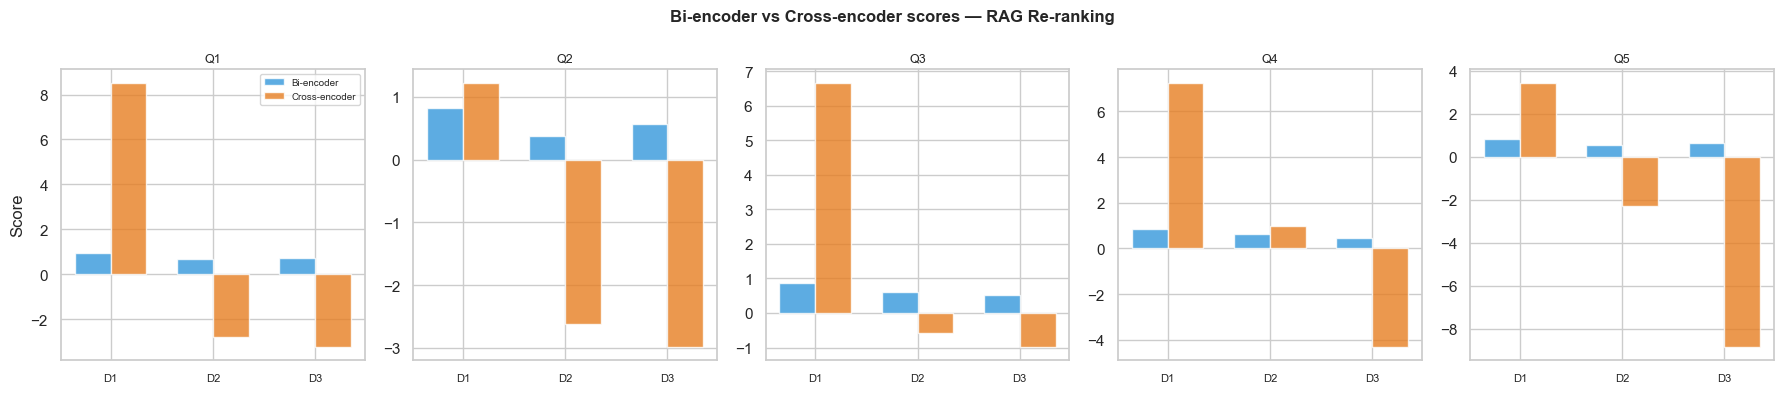

 Graphique sauvegardé dans ../Charts/05_rerank_scores.png


In [18]:
fig, axes = plt.subplots(1, len(TEST_QUERIES), figsize=(18, 4), sharey=False)

for i, (result, ax) in enumerate(zip(rerank_results, axes)):
    docs = result['retrieved_docs']
    x    = np.arange(len(docs))
    w    = 0.35
    bi   = [d['bi_score'] for d in docs]
    cr   = [d['cross_score'] for d in docs]

    ax.bar(x - w/2, bi, w, label='Bi-encoder', color='#3498db', alpha=0.8)
    ax.bar(x + w/2, cr, w, label='Cross-encoder', color='#e67e22', alpha=0.8)
    ax.set_title(f'Q{i+1}', fontsize=9)
    ax.set_xticks(x)
    ax.set_xticklabels([f'D{j+1}' for j in range(len(docs))], fontsize=8)
    if i == 0:
        ax.legend(fontsize=7)
        ax.set_ylabel('Score')

plt.suptitle('Bi-encoder vs Cross-encoder scores — RAG Re-ranking', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('../Charts/05_rerank_scores.png', dpi=150)
plt.show()
print(' Graphique sauvegardé dans ../Charts/05_rerank_scores.png')

## 10. Sauvegarde

In [19]:
with open('../Results/results_rag_rerank.json', 'w', encoding='utf-8') as f:
    json.dump(rerank_results, f, ensure_ascii=False, indent=2)
print(' Résultats sauvegardés dans ../Results/results_rag_rerank.json')

 Résultats sauvegardés dans ../Results/results_rag_rerank.json


---
## ✅ Résumé

| Étape | Détail |
|---|---|
| Bi-encodeur | `all-MiniLM-L6-v2` |
| Cross-encodeur | `cross-encoder/ms-marco-MiniLM-L-6-v2` |
| Top-k retrieval | 3 documents |
| LLM | `google/flan-t5-base` |
| Temps moyen | ~32s / requête (CPU) |
| Fichier de sortie | `results_rag_reranking.json` |

### Résultats obtenus

| # | Requête | 1er doc (cross) | Pertinence |
|---|---|---|---|
| Q1 | Scan SYN | +8.53 | ✅ Très pertinent |
| Q2 | Brute Force SSH | +1.22 | ✅ Pertinent |
| Q3 | Injection SQL | +6.66 | ✅ Très pertinent |
| Q4 | Ransomware SMB | +7.26 | ✅ Très pertinent |
| Q5 | Exfiltration DNS | +3.46 | ✅ Pertinent |

### Améliorations constatées vs RAG Classic
- ✅ Le cross-encodeur sépare nettement le doc pertinent des autres (scores négatifs pour les candidats faibles)
- ✅ Meilleure précision sémantique — ex: Q3 passe de bi=0.86 à cross=+6.66
- ✅ Aucun faux positif classé premier

### Limites observées
- ❌ `sid` toujours absent dans les règles générées
- ❌ Syntaxe Snort encore approximative (champs non valides)
- ⚠️ Légèrement plus lent que le RAG classic (~+4s) à cause du re-ranking

### Conclusion
Le re-ranking améliore la **sélection des documents** de façon visible.
Le goulot d'étranglement reste le LLM, incapable de produire une syntaxe Snort rigoureuse.
L'architecture hybride devrait combiner recall large et précision accrue.